<a href="https://colab.research.google.com/github/HEISENBERG-PV/Customer_Segementattion_Project/blob/main/Customer_Segementation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


# **Setting the DataSet**

In [ ]:
np.random.seed(42)
data = {
    'CustomerID': np.arange(1, 1001),
    'Age': np.random.randint(18, 65, size=1000),
    'Average_Time_Spend' : np.random.uniform(5, 60, size=1000),
    'Visit_per_week': np.random.randint(5, 10, size=1000),
    'Promotion_Interest': np.random.randint(0, 3, size=1000)
}
df = pd.DataFrame(data)
df['Promotion_Interest'].value_counts()

,count
Promotion_Interest,
0,348
2,333
1,319


# **Finding the optimal Cluster Num**

In [ ]:
features = df[['Age', 'Average_Time_Spend', 'Visit_per_week', 'Promotion_Interest']]
inertia = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(features)
  inertia.append(kmeans.inertia_)

inertia

[440742.08435815474,
 246790.16086882565,
 164951.86893602498,
 112883.98341353548,
 92013.1323687424,
 74585.29965450289,
 66644.86308885484,
 57398.65120746549,
 50051.31571099978,
 44955.34633150734]

# **Making Elbow Method Graph**

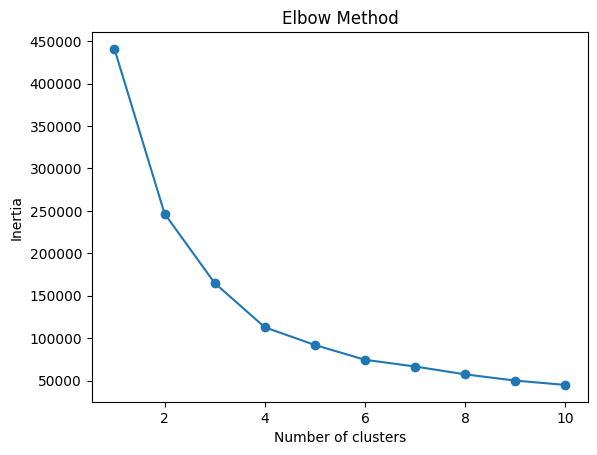

In [ ]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# **Final KMeans clustering with cluster num = 3**

In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans_final.fit_predict(features)
df

,CustomerID,Age,Average_Time_Spend,Visit_per_week,Promotion_Interest,cluster
0,1,56,22.729461,9,1,2
1,2,46,49.543095,7,2,0
2,3,32,19.005236,6,2,2
3,4,60,42.482650,8,2,0
4,5,25,46.812532,7,2,1
...,...,...,...,...,...,...
995,996,22,28.787383,8,1,1
996,997,40,22.149887,6,2,2
997,998,27,32.837802,8,2,1
998,999,61,29.173143,7,1,0


# **Mapping the cluster val**

In [ ]:
cluster_name = {0: 'Daily', 1: 'Promotion', 2: 'Weekend'}
df['cluster'] = df['cluster'].map(cluster_name)
df

,CustomerID,Age,Average_Time_Spend,Visit_per_week,Promotion_Interest,cluster
0,1,56,22.729461,9,1,Weekend
1,2,46,49.543095,7,2,Daily
2,3,32,19.005236,6,2,Weekend
3,4,60,42.482650,8,2,Daily
4,5,25,46.812532,7,2,Promotion
...,...,...,...,...,...,...
995,996,22,28.787383,8,1,Promotion
996,997,40,22.149887,6,2,Weekend
997,998,27,32.837802,8,2,Promotion
998,999,61,29.173143,7,1,Daily


In [ ]:
df['cluster'].value_counts()

,count
cluster,
Weekend,416
Daily,294
Promotion,290


# **Storing the Kmeans Model with Pickle**

In [ ]:
import pickle

with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

In [ ]:
kmeans = pickle.load(open("kmeans.pkl", "rb"))
kmeans

KMeans(n_clusters=3, random_state=42)

# **Finding the cluster for new customer**

In [ ]:
def find_cluster(age, average_time_spend, visit_per_week, promotion_interest):
  cluster = kmeans.predict([[age, average_time_spend, visit_per_week, promotion_interest]])

  if cluster[0] == 0:
    return 'Daily'
  elif cluster[0] == 1:
    return 'Promotion'
  else:
    return 'Weekend'

In [ ]:
age = 30
average_time_spend = 20
visit_per_week = 5
promotion_interest = 1

predicted = find_cluster(age, average_time_spend, visit_per_week, promotion_interest)
print("New customer assign to ", predicted)

New customer assign to  Weekend


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
import os
print(os.listdir())

['.config', 'kmeans.pkl', 'sample_data']
